# Import Library dan Dataset

In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [88]:
#import dataset
df_train = pd.read_csv("train.csv")
df_train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [89]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

# Preprocessing

In [90]:
#cek duplikat
df_train.duplicated().sum()

np.int64(0)

In [91]:
#cek tipe data 
print(df_train['MonthlyCharges'].dtype)
print(df_train['TotalCharges'].dtype)

float64
float64


In [92]:
df_train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


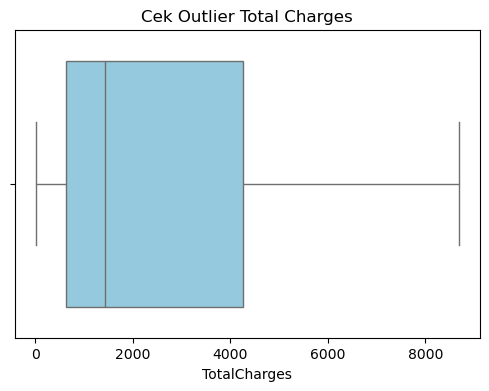

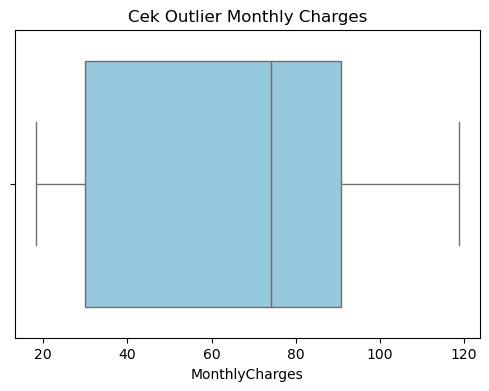

In [93]:
#cek outlier
plt.figure(figsize = (6,4))
sns.boxplot(x = df_train['TotalCharges'], color = 'skyblue')
plt.title('Cek Outlier Total Charges')
plt.show()

plt.figure(figsize = (6,4))
sns.boxplot(x = df_train['MonthlyCharges'], color ='skyblue')
plt.title('Cek Outlier Monthly Charges')
plt.show()

# EDA

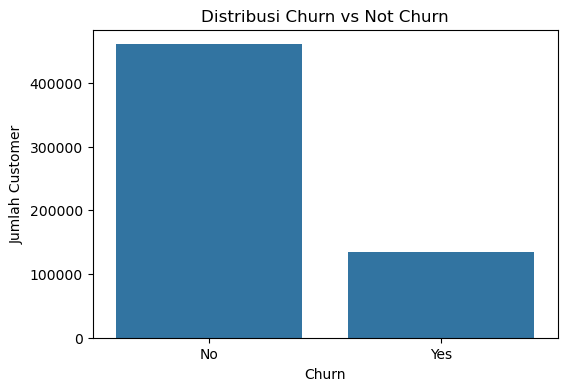

In [94]:
#Univariat Analysis (Melihat distribusi)
#Churn vs Not Churn
plt.figure(figsize = (6,4))
sns.countplot(data = df_train, x = 'Churn')
plt.title('Distribusi Churn vs Not Churn')
plt.ylabel('Jumlah Customer')
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_3484\3609262786.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_train[df_train["Churn"]== 'Yes']['tenure'], label = 'Churn : Yes', shade=True, color = 'red')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_3484\3609262786.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_train[df_train['Churn']=='No']['tenure'], label = 'Churn : No', shade=True, color ='blue')


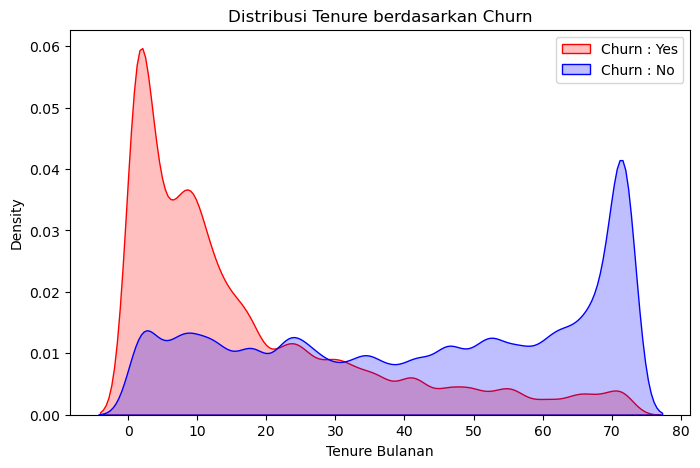

In [95]:
#Bivariate Analysis 
#Korelasi Tenure vs Churn
plt.figure(figsize = (8,5))
#plot untuk pelanggan yang churn
sns.kdeplot(df_train[df_train["Churn"]== 'Yes']['tenure'], label = 'Churn : Yes', shade=True, color = 'red')
#plot untuk pelanggan yang Tidak Churn
sns.kdeplot(df_train[df_train['Churn']=='No']['tenure'], label = 'Churn : No', shade=True, color ='blue')
plt.title('Distribusi Tenure berdasarkan Churn')
plt.xlabel('Tenure Bulanan')
plt.ylabel('Density')
plt.legend()
plt.show()

* Insight : Pelanggan dengan churn tertinggi berada di 0 - 10 bulan, bulan-bulan awal adalah masa paling kritis dimana pelanggan baru cenderung lebih mudah untuk berhenti berlangganan
* Action : berikan "Loyalty Program" atau "Onboarding Experience" yang lebih baik di 6 bulan pertama
* Goal : Untuk menekan angka churn  

C:\Users\lenovo\AppData\Local\Temp\ipykernel_3484\424532167.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_train[df_train['Churn']=='Yes']['MonthlyCharges'], label = 'Churn : Yes', shade = True, color = 'red')
C:\Users\lenovo\AppData\Local\Temp\ipykernel_3484\424532167.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_train[df_train['Churn']=='No']['MonthlyCharges'], label = 'Churn : No', shade = True, color = 'blue')


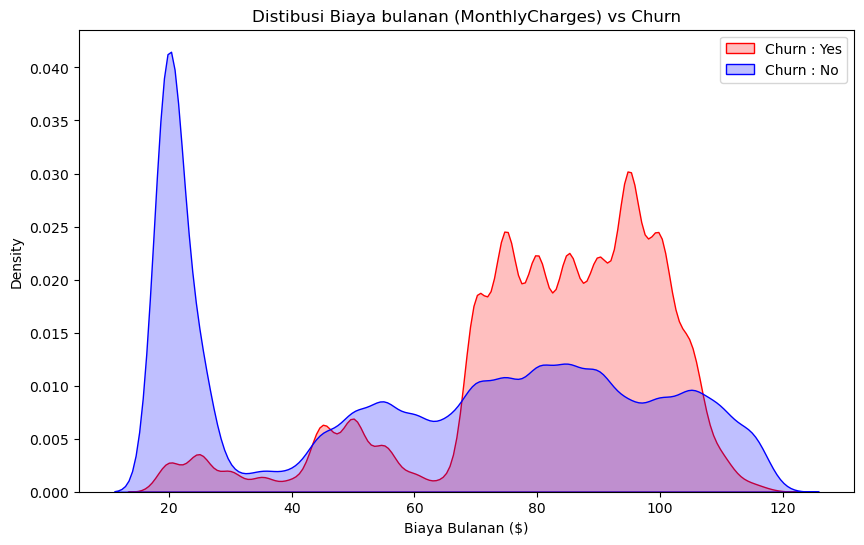

In [96]:
#korelasi untuk melihat hubungan antara MonthlyCharges dan Churn

plt.figure(figsize = (10,6))
#distribusi monthlycharger untuk pelanggan yang Churn
sns.kdeplot(df_train[df_train['Churn']=='Yes']['MonthlyCharges'], label = 'Churn : Yes', shade = True, color = 'red')
sns.kdeplot(df_train[df_train['Churn']=='No']['MonthlyCharges'], label = 'Churn : No', shade = True, color = 'blue')
plt.title('Distibusi Biaya bulanan (MonthlyCharges) vs Churn')
plt.xlabel('Biaya Bulanan ($)')
plt.ylabel('Density')
plt.legend()
plt.show()

In [97]:
from scipy.stats import pointbiserialr

# Pastikan Churn sudah numerik (1 untuk Yes, 0 untuk No)
df_train['Churn_Binary'] = df_train['Churn'].map({'Yes': 1, 'No': 0})

# Hitung korelasi
corr, p_value = pointbiserialr(df_train['Churn_Binary'], df_train['MonthlyCharges'])

print(f"Koefisien Korelasi: {corr:.4f}")
print(f"P-Value: {p_value:.4f}")

Koefisien Korelasi: 0.2730
P-Value: 0.0000


1. Segmen Resiko Tinggi
   * Insight : Pelanggan dengan tagihan bulanan lebih dari $60 memiliki  kecenderungan Churn yang jauh lebih tinggi
   * Action : Tim marketing/sales harus meluncurkan "High-Value retention Program". Berikan penawaran khusus, diskon loyalitas, atau upgrade layanan gratis bagi pelanggan di segmen harga sebelum kontrak mereka berakhir
   *  Goal : Menurunkan churn rate pada segmen pelanggan yang memberikan pendapatan (ARPU- Average revenue Per User) tertinggi bagi perusahaan
2. Evaluasi Price - to Value Ratio
   * Insight : Korelasi positif menunjukan bahwa semakin mahal biaya, semakin besar keinginan pelanggan untuk pindah
   * Action : Lakukan survei kepuasan pelanggan khusus untuk pengguna paket premium, dan periksa apakah dasilitas yang pelanggan dapatkan sebanding dengan harganya.
   * Goal : Memastikan value yang dirasakan pelanggan sesuai dengan harga yang dibayar agar mereka tidak merasa dirugika

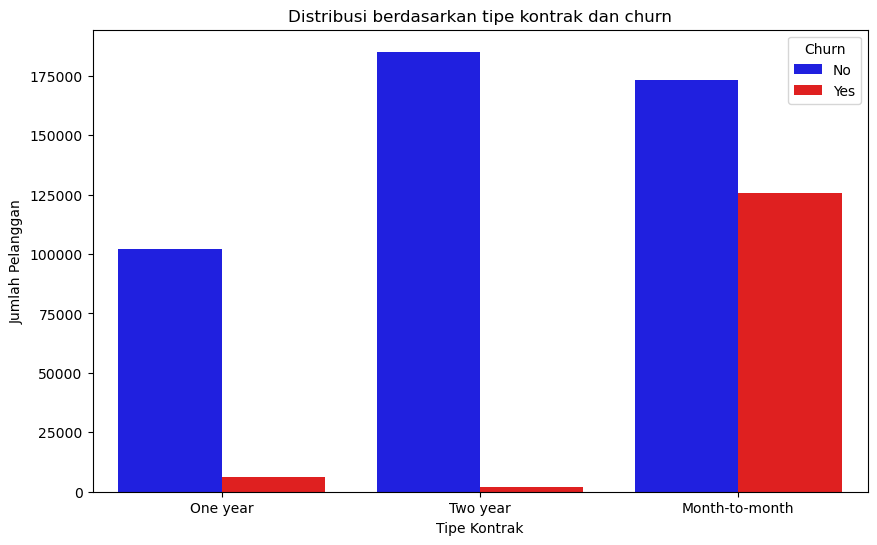

In [98]:
#Churn rate by Contract
plt.figure(figsize = (10,6))
sns.countplot(data = df_train, x = 'Contract', hue = 'Churn', palette={'Yes': 'red', 'No': 'blue'})
plt.title('Distribusi berdasarkan tipe kontrak dan churn')
plt.xlabel('Tipe Kontrak')
plt.ylabel('Jumlah Pelanggan')
plt.legend(title = 'Churn')
plt.show()

# Feature Engineering (Encoding)

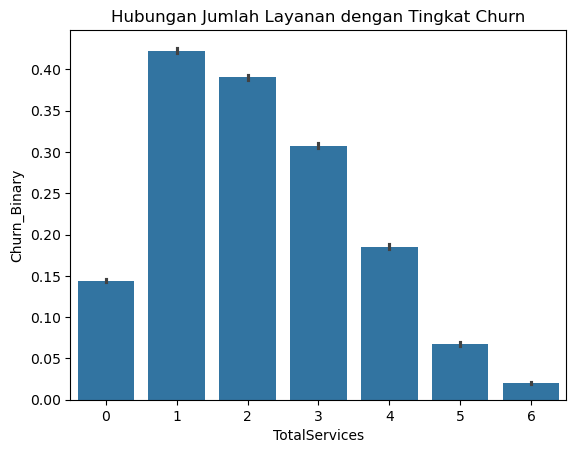

In [99]:
#Membuat feature baru (Total Service)
#Daftar kolom layanan
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Hitung jumlah layanan 'Yes' per baris
df_train['TotalServices'] = (df_train[services] == 'Yes').sum(axis=1)

# Visualisasikan hubungannya dengan Churn
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='TotalServices', y='Churn_Binary', data=df_train)
plt.title('Hubungan Jumlah Layanan dengan Tingkat Churn')
plt.show()

In [100]:
#Mengelompokan Tenure (Tenure Group)
def group_tenure(t):
    if t <= 12: return '0-1 Year'
    elif t <= 24: return '1-2 Years'
    elif t <= 48: return '2-4 Years'
    else: return '> 4 Years'

df_train['Tenure_Group'] = df_train['tenure'].apply(group_tenure)

## Encoding

In [101]:
#Ordinal Encoding 
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_train['Contract_Encoded'] = df_train['Contract'].map(contract_map)

In [102]:
#Binary Encoding
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_train[col] = df_train[col].map({'Yes': 1, 'No': 0})
    
# Khusus Gender
df_train['gender'] = df_train['gender'].map({'Male': 1, 'Female': 0})

In [103]:
#One Hot Encoding
df_train = pd.get_dummies(df_train, columns=['InternetService', 'PaymentMethod', 'Tenure_Group', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup','DeviceProtection', 'TechSupport', 'StreamingTV','StreamingMovies', 'Contract'], drop_first=True)

In [104]:
!pip install xgboost

# Modeling dan Evaluation

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [106]:
#Persiapan data (X dan y)
#hapus kolom ID dan target dari fitur
X = df_train.drop(['id', 'Churn', 'Churn_Binary'], axis = 1)
y = df_train['Churn_Binary']

In [107]:
#Feature Scaling
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']
X[num_cols] = scaler.fit_transform(X[num_cols])

In [108]:
#split Data (Training & Validation)
# Stratify=y memastikan proporsi churn di train dan test tetap sama
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [109]:
#Training Model dengan XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

D:\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:57:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [110]:
#Prediksi dan evaluasi
y_pred = xgb_model.predict(X_val)
y_prob = xgb_model.predict_proba(X_val)[:, 1] #untuk AUC-ROC

print("--- Evaluation Report ---")
print(classification_report(y_val, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_prob):.4f}")

--- Evaluation Report ---
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.71      0.64      0.67     26763

    accuracy                           0.86    118839
   macro avg       0.80      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839

ROC-AUC Score: 0.9151


# Data Test

In [111]:
#load data test
df_test = pd.read_csv("test.csv")
df_test

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254650,848844,Male,0,Yes,Yes,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.95,1443.65
254651,848845,Male,1,Yes,No,16,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,100.15,1563.50
254652,848846,Male,0,Yes,No,35,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),105.80,3132.75
254653,848847,Female,0,No,No,25,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.25,511.25


In [112]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                254655 non-null  int64  
 1   gender            254655 non-null  object 
 2   SeniorCitizen     254655 non-null  int64  
 3   Partner           254655 non-null  object 
 4   Dependents        254655 non-null  object 
 5   tenure            254655 non-null  int64  
 6   PhoneService      254655 non-null  object 
 7   MultipleLines     254655 non-null  object 
 8   InternetService   254655 non-null  object 
 9   OnlineSecurity    254655 non-null  object 
 10  OnlineBackup      254655 non-null  object 
 11  DeviceProtection  254655 non-null  object 
 12  TechSupport       254655 non-null  object 
 13  StreamingTV       254655 non-null  object 
 14  StreamingMovies   254655 non-null  object 
 15  Contract          254655 non-null  object 
 16  PaperlessBilling  25

In [113]:
#simpan kolom 'id' untuk kebutuhan submission anti
test_id = df_test['id']

In [114]:
#feature engineering
df_test['TotalServices'] = (df_test[services] == 'Yes').sum(axis=1)
df_test['Contract_Encoded'] = df_test['Contract'].map(contract_map)
df_test['gender'] = df_test['gender'].map({'Male': 1, 'Female': 0})

In [115]:
# Mapping binary columns
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    df_test[col] = df_test[col].map({'Yes': 1, 'No': 0})

In [117]:
# One-Hot Encoding
# Pastikan kolom hasil get_dummies di Test sama persis dengan di Train
# Pastikan menggunakan df_test sebagai input
df_test = pd.get_dummies(df_test, columns=[
    'InternetService', 'PaymentMethod','MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract'
], drop_first=True)

In [118]:
# Menyamakan kolom Test agar sama dengan Train (X_train adalah fitur saat modeling)
df_test = df_test.reindex(columns = X_train.columns, fill_value=0)

In [119]:
# 1. Scaling
df_test[num_cols] = scaler.transform(df_test[num_cols])

# 2. Prediksi Probabilitas (Kaggle biasanya minta probabilitas untuk AUC-ROC)
test_predictions = xgb_model.predict_proba(df_test)[:, 1]

# 3. Prediksi Label (0 atau 1)
test_labels = xgb_model.predict(df_test)

In [120]:
submission = pd.DataFrame({
    'id': test_id,
    'Churn': test_predictions # Gunakan probabilitas jika diminta AUC
})

submission.to_csv('submission_Ade_Krisna.csv', index=False)
print("File submission berhasil dibuat!")

File submission berhasil dibuat!


In [122]:
df_sub = pd.read_csv('submission_Ade_Krisna.csv')
df_sub

,id,Churn
0,594194,0.067465
1,594195,0.001086
2,594196,0.089905
3,594197,0.003583
4,594198,0.531077
...,...,...
254650,848844,0.000681
254651,848845,0.801818
254652,848846,0.312482
254653,848847,0.003992
